In [1]:
pip install gradio


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pandas


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install ollama

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#ural = r"D:\Data Science\DS_prakash_senapati\Notes prakash sir\april(2025)-1\april(2025)\3th- EDA Automation Mistral, gradio\3th- EDA Automation Mistral, gradio\titanic_ dataset_final.csv"
# or 
ural = r"titanic_ dataset_final.csv"

df = pd.read_csv(ural)
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [7]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [8]:
print("\nMissing Values:\n" , df.isnull().sum() )


Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


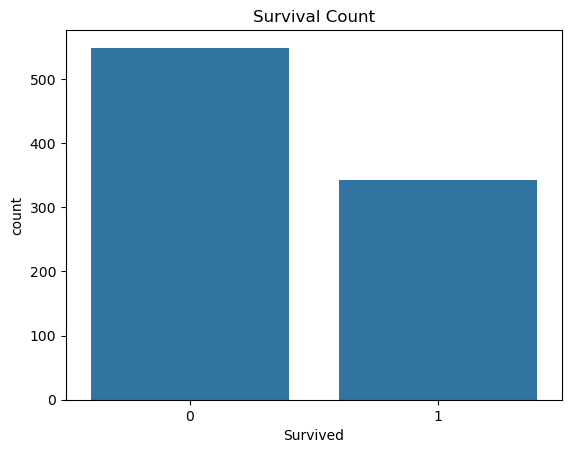

In [9]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

In [ ]:
# Ollama is an open-source tool used to easily run large language models (LLMs) like Llama 3, Mixtral, and Codestral locally on your own computer
import ollama

def generate_insights(df_summary):
    prompt = f"In 3 bullet points, analyze this data:\n{df_summary}"
    response = ollama.chat(model="tinyllama", messages=[{"role": "user", "content": prompt}])
    return response.message.content  # dot notation

# Send only 200 characters of summary
summary = df.describe().to_string()[:200]
print("Sending... please wait ~1-2 min")
insights = generate_insights(summary)
print("\nAI Generated Insights:\n", insights)

Sending... please wait ~1-2 min

AI Generated Insights:
 1. **PassengerId**: This is the unique identifier for each passenger on the Titanic. A passenger's survival or not is determined by their seat assignment, which is reflected in their PassengerId.

2. **Survived**: This is the proportion of passengers who survived the sinking of the Titanic. Passengers who survived were marked as "Survived" in the data.

3. **Pclass**: This is a social status classification system that assigns passengers to different classes based on their economic background. The passengers in upper classes were considered to be more privileged, more likely to have more expensive luxury items, and therefore were more likely to survive.

4. **Age**: The data reflects the age of each passenger on the Titanic. Passengers of all ages were included in the analysis.

5. **SiBSp**: This variable indicates whether a passenger was a "sibling spouse" or not. A sibling spouse is defined as a passenger who was related to a p

In [ ]:
# Gradio is an open-source Python library used to rapidly build and share interactive web-based user interfaces (UIs) for machine learning models, APIs, or data science workflows
import gradio as gr
def eda_analysis(file):
    df = pd.read_csv(file.name)
    summary = df.describe().to_string()
    insights = generate_insights(summary)
    return insights
# web interface 
demo = gr.Interface(fn=eda_analysis,inputs="file",outputs="text", title=" AI powered EDA with mistral")
# launch app
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


In [12]:
import gradio as gr

def greet(name):
    return "Hello " + name + "!"

demo = gr.Interface(fn=greet, inputs="text", outputs="text")
demo.launch()   

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


Created dataset file at: .gradio\flagged\dataset2.csv
